# Demo experiment, May 4, Gabriele Bettineschi


**Trait:** sentiment  
**Model:** `google/gemma-2-2b` (base, completion)  
**Layer:** 13, central (there are 26 layers in total) 

In [ ]:
import sys
from pathlib import Path

import torch

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from data import Sample
from representations import load_model, extract_activations
from analysis import compute_difference_vectors, similarity_matrix, plot_similarity_matrix

In [ ]:
MODEL  = "google/gemma-2-2b"
LAYER  = 13
TRAIT  = "sentiment"
LEVELS = ["negative", "neutral", "positive"]

# "sad / okay / happy" are moderate-arousal and genuinely linearly ordered on sentiment.
# Avoids the arousal confound of "miserable / indifferent / wonderful"
# (miserable and wonderful are both high-arousal; indifferent is low-arousal,
#  making the two step directions point opposite in activation space).
PROMPTS = {
    "negative": "She felt completely sad",
    "neutral":  "She felt completely okay",
    "positive": "She felt completely happy",
}

TRAITS_CFG = [{"name": TRAIT, "intensities": LEVELS}]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cpu


In [ ]:
# slow — run once
model, tokenizer = load_model(MODEL, device)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [ ]:
samples = [Sample(prompt=PROMPTS[lvl], trait=TRAIT, intensity=lvl) for lvl in LEVELS]
activations = extract_activations(samples, model, tokenizer, LAYER, device)

for (trait, intensity), vec in activations.items():
    print(f"  ({trait}, {intensity}): shape={vec.shape}, norm={vec.norm():.2f}")

  (sentiment, negative): shape=torch.Size([2304]), norm=185.36
  (sentiment, neutral): shape=torch.Size([2304]), norm=177.95
  (sentiment, positive): shape=torch.Size([2304]), norm=182.28


In [ ]:
diffs = compute_difference_vectors(activations, TRAITS_CFG)

for (trait, lo, hi), vec in diffs.items():
    print(f"  {trait}: {lo} → {hi}  norm={vec.norm():.2f}")

  sentiment: negative → neutral  norm=129.76
  sentiment: neutral → positive  norm=104.77


In [ ]:
labels, matrix = similarity_matrix(diffs)

print("Cosine similarity matrix:")
header = f"{'':>20}" + "".join(f"{l:>22}" for l in labels)
print(header)
for i, li in enumerate(labels):
    row = f"{li:>20}" + "".join(f"{matrix[i, j]:>22.4f}" for j in range(len(labels)))
    print(row)

print(f"\nKey number — cosine similarity (neg→neu) vs (neu→pos): {matrix[0, 1]:.4f}")

Cosine similarity matrix:
                    sentiment:negative→neutralsentiment:neutral→positive
sentiment:negative→neutral                1.0000               -0.6389
sentiment:neutral→positive               -0.6389                1.0000

Key number — cosine similarity (neg→neu) vs (neu→pos): -0.6389


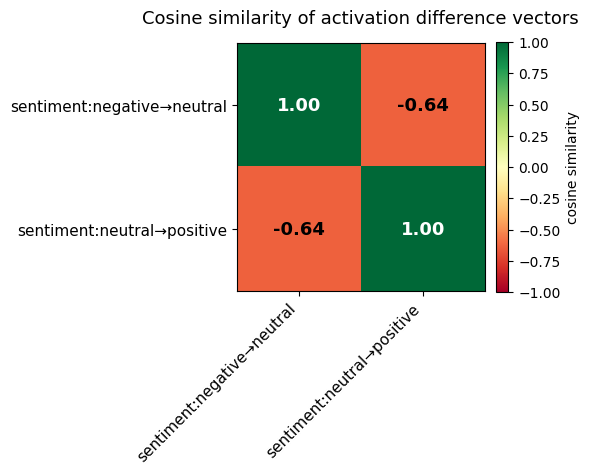

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

n = len(labels)
cell = 2.2
fig, ax = plt.subplots(figsize=(max(6, n * cell), max(6, n * cell)))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i, j in itertools.product(range(n), range(n)):
    color = "white" if abs(matrix[i, j]) > 0.65 else "black"
    ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
            fontsize=13, fontweight="bold", color=color)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("cosine similarity", fontsize=10)
ax.set_title("Cosine similarity of activation difference vectors", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

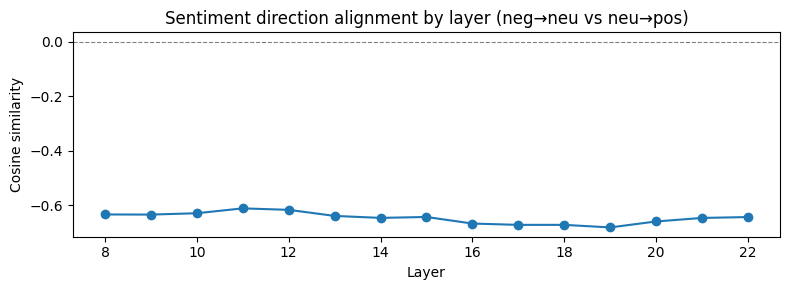

In [ ]:
import matplotlib.pyplot as plt

sweep_layers = range(8, 23)
sims = []

for layer in sweep_layers:
    acts = extract_activations(samples, model, tokenizer, layer, device)
    d = compute_difference_vectors(acts, TRAITS_CFG)
    _, m = similarity_matrix(d)
    sims.append(m[0, 1])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(list(sweep_layers), sims, marker="o", linewidth=1.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Sentiment direction alignment by layer (neg→neu vs neu→pos)")
plt.tight_layout()
plt.show()